1. Data Preprocessing

2. Data spliting

=== Initial Data Overview ===
Training set shape: (891, 12)
Test set shape: (418, 11)



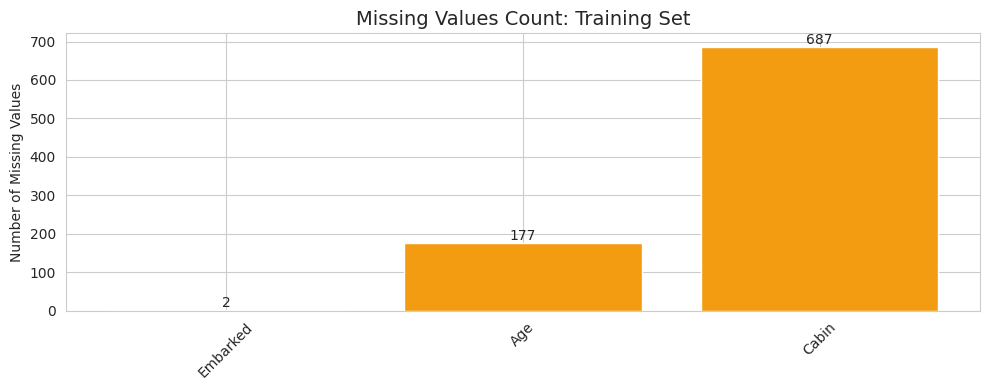

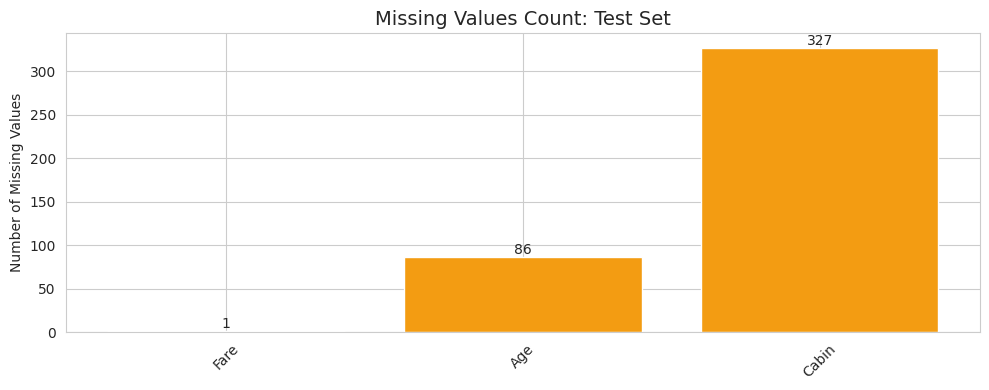


=== After Handling Missing Values ===
Missing values in training set:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

Missing values in test set:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64


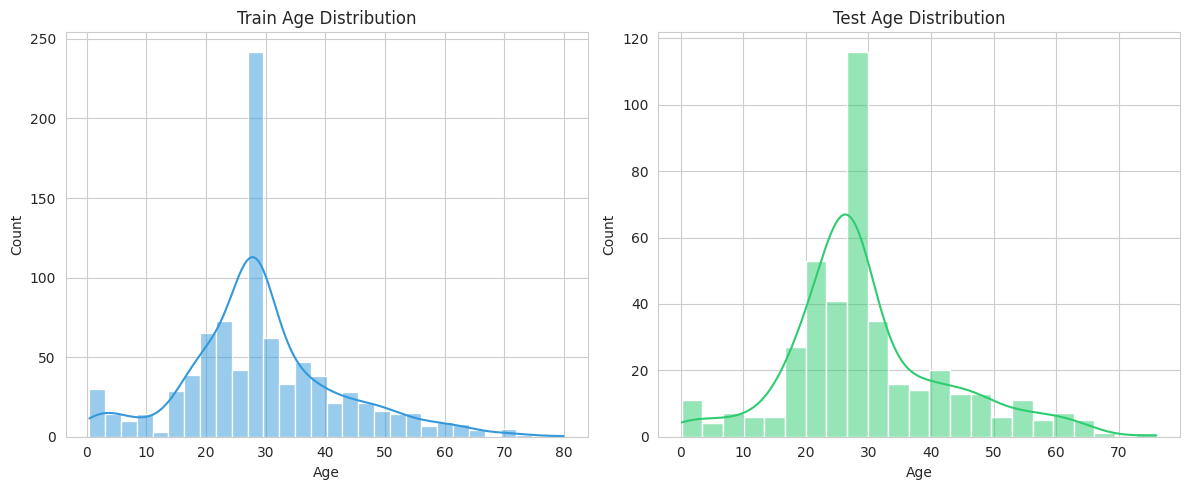

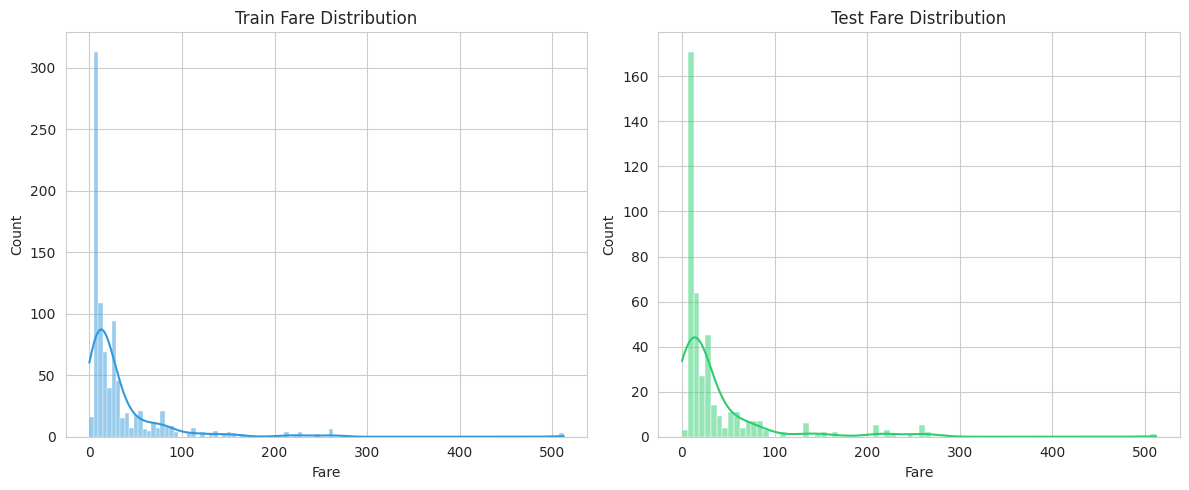

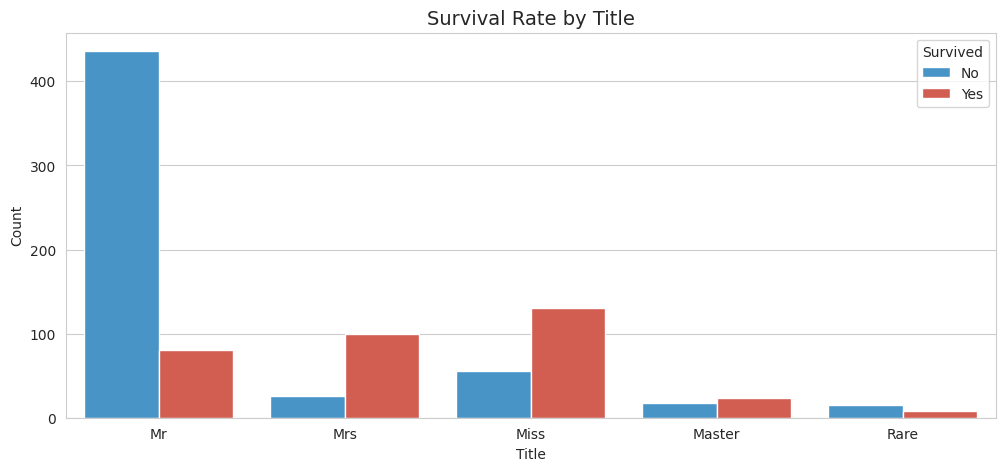

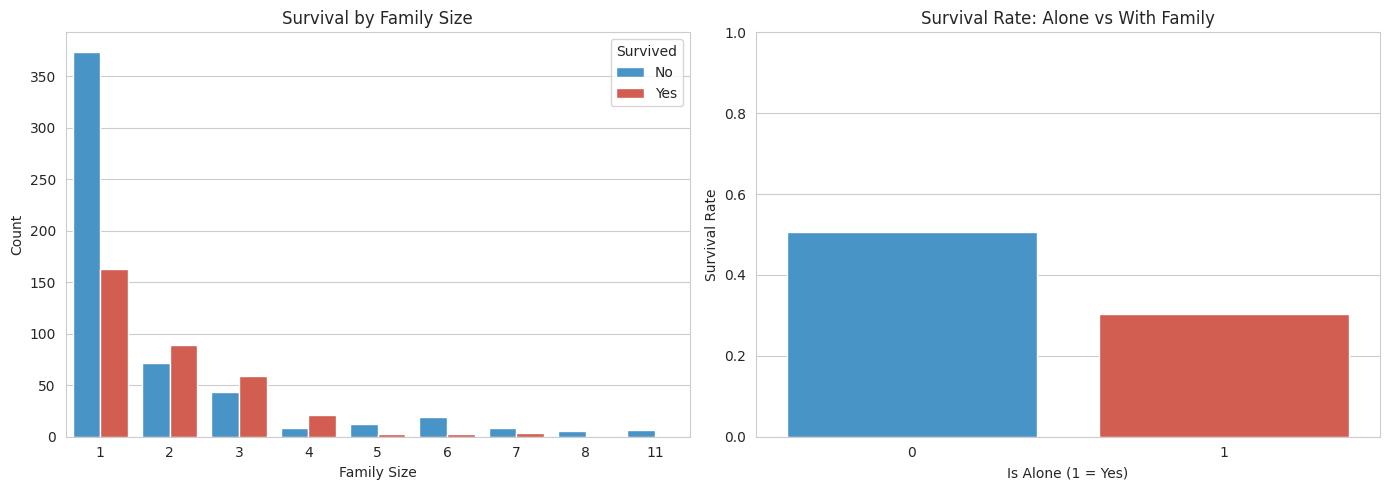


=== Final Features ===
Training set columns: ['Survived', 'Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Pclass_1', 'Pclass_2', 'Pclass_3', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']

=== Feature Scaling Visualization ===


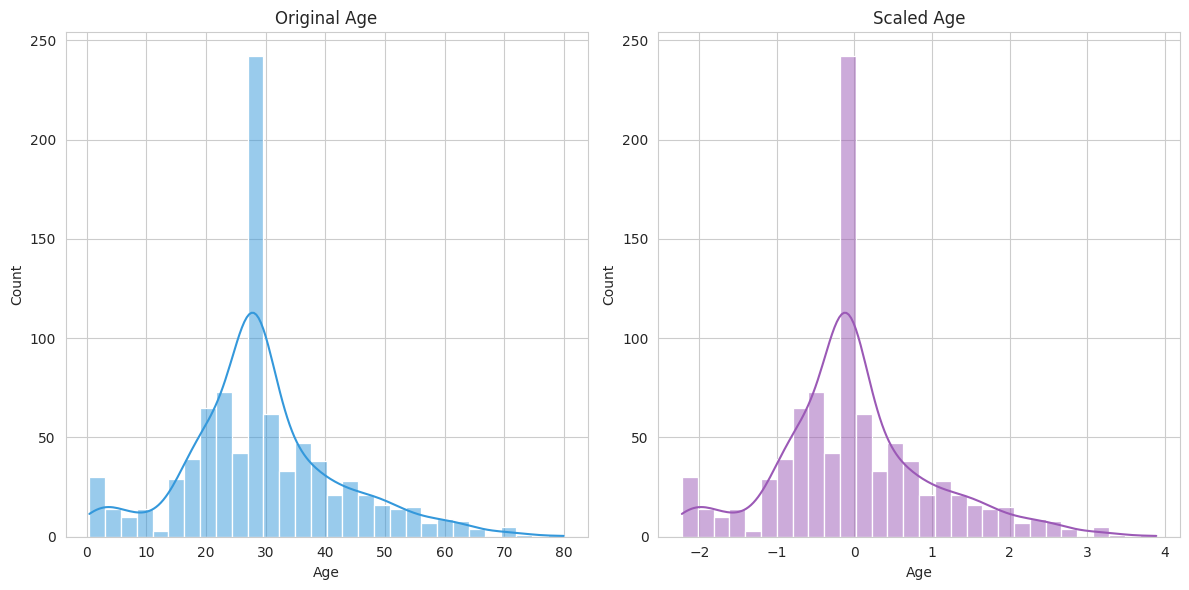


=== Processed Data Samples ===
Training Data:
        Sex       Age      Fare  FamilySize   IsAlone  Embarked_C  Embarked_Q  \
0 -0.737695 -0.565736 -0.502445    0.059160 -1.231645   -0.482043   -0.307562   
1  1.355574  0.663861  0.786845    0.059160 -1.231645    2.074505   -0.307562   
2  1.355574 -0.258337 -0.488854   -0.560975  0.811922   -0.482043   -0.307562   
3  1.355574  0.433312  0.420730    0.059160 -1.231645   -0.482043   -0.307562   
4 -0.737695  0.433312 -0.486337   -0.560975  0.811922   -0.482043   -0.307562   

   Embarked_S  Pclass_1  Pclass_2  Pclass_3  Title_Master  Title_Miss  \
0    0.615838 -0.565685 -0.510152  0.902587     -0.216803   -0.511898   
1   -1.623803  1.767767 -0.510152 -1.107926     -0.216803   -0.511898   
2    0.615838 -0.565685 -0.510152  0.902587     -0.216803    1.953514   
3    0.615838  1.767767 -0.510152 -1.107926     -0.216803   -0.511898   
4    0.615838 -0.565685 -0.510152  0.902587     -0.216803   -0.511898   

   Title_Mr  Title_Mrs  Tit

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
survival_palette = ['#3498db', '#e74c3c']  # Blue for survived, red for not survived

def plot_missing_values(df, title):
    """Improved missing values visualization"""
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    missing.sort_values(inplace=True)

    plt.figure(figsize=(10, 4))
    bars = plt.bar(missing.index, missing.values, color='#f39c12')

    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:,}',
                ha='center', va='bottom')

    plt.title(f'Missing Values Count: {title}', fontsize=14)
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_feature_distribution(feature, train, test=None, kde=True):
    """Compare feature distributions between train and test sets"""
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(train[feature], kde=kde, color='#3498db')
    plt.title(f'Train {feature} Distribution')

    if test is not None:
        plt.subplot(1, 2, 2)
        sns.histplot(test[feature], kde=kde, color='#2ecc71')
        plt.title(f'Test {feature} Distribution')

    plt.tight_layout()
    plt.show()

def preprocess_titanic_data(train_path='train.csv', test_path='test.csv', visualize=True):
    """
    Final optimized preprocessing pipeline with all warnings resolved
    Returns:
    - X_train (DataFrame): Processed training features
    - y_train (Series): Training target (Survived)
    - X_test (DataFrame): Processed test features
    - scaler (StandardScaler): Fitted scaler for later use
    """

    # Load raw data
    train_df = pd.read_csv(train_path).copy()
    test_df = pd.read_csv(test_path).copy()

    if visualize:
        print("=== Initial Data Overview ===")
        print(f"Training set shape: {train_df.shape}")
        print(f"Test set shape: {test_df.shape}\n")

        plot_missing_values(train_df, 'Training Set')
        plot_missing_values(test_df, 'Test Set')

    ## ======================
    ## 1. Handle Missing Values
    ## ======================

    # Age - Fill with median
    train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
    test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())

    # Embarked - Fill with mode (only in train)
    train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

    # Fare - Fill with median (only in test)
    test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())

    if visualize:
        print("\n=== After Handling Missing Values ===")
        print("Missing values in training set:")
        print(train_df.isnull().sum())
        print("\nMissing values in test set:")
        print(test_df.isnull().sum())

        plot_feature_distribution('Age', train_df, test_df)
        plot_feature_distribution('Fare', train_df, test_df)

    ## ======================
    ## 2. Feature Engineering
    ## ======================

    # Convert Sex to binary
    train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})
    test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})

    # Extract titles from names
    for df in [train_df, test_df]:
        df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

        # Consolidate rare titles
        rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
                      'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
        df['Title'] = df['Title'].replace(rare_titles, 'Rare')

        # Standardize titles
        df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
        df['Title'] = df['Title'].replace('Mme', 'Mrs')

    if visualize:
        plt.figure(figsize=(12, 5))
        sns.countplot(data=train_df, x='Title', hue='Survived', palette=survival_palette)
        plt.title('Survival Rate by Title', fontsize=14)
        plt.xlabel('Title')
        plt.ylabel('Count')
        plt.legend(title='Survived', labels=['No', 'Yes'])
        plt.show()

    # Create family features
    for df in [train_df, test_df]:
        df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
        df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    if visualize:
        plt.figure(figsize=(14, 5))

        # Family Size plot
        plt.subplot(1, 2, 1)
        sns.countplot(data=train_df, x='FamilySize', hue='Survived', palette=survival_palette)
        plt.title('Survival by Family Size')
        plt.xlabel('Family Size')
        plt.ylabel('Count')
        plt.legend(title='Survived', labels=['No', 'Yes'])

        # IsAlone plot - Fixed warning by using proper hue assignment
        plt.subplot(1, 2, 2)
        sns.barplot(data=train_df, x='IsAlone', y='Survived',
                   hue='IsAlone', palette=survival_palette,
                   errorbar=None, legend=False)
        plt.title('Survival Rate: Alone vs With Family')
        plt.xlabel('Is Alone (1 = Yes)')
        plt.ylabel('Survival Rate')
        plt.ylim(0, 1)

        plt.tight_layout()
        plt.show()

    ## ======================
    ## 3. Encode Categorical Variables
    ## ======================

    # One-hot encoding for categorical features
    categorical_cols = ['Embarked', 'Pclass', 'Title']

    train_df = pd.get_dummies(train_df, columns=categorical_cols)
    test_df = pd.get_dummies(test_df, columns=categorical_cols)

    # Ensure both datasets have the same columns
    for col in set(train_df.columns) - set(test_df.columns):
        if col != 'Survived':
            test_df[col] = 0

    # Reorder columns to match train set
    test_df = test_df[train_df.drop('Survived', axis=1).columns]

    ## ======================
    ## 4. Drop Irrelevant Features
    ## ======================
    drop_cols = ['Name', 'Ticket', 'Cabin', 'PassengerId', 'SibSp', 'Parch']
    train_df = train_df.drop(drop_cols, axis=1)
    test_df = test_df.drop(drop_cols, axis=1)

    if visualize:
        print("\n=== Final Features ===")
        print("Training set columns:", list(train_df.columns))

    ## ======================
    ## 5. Split Features and Target
    ## ======================
    X_train = train_df.drop('Survived', axis=1)
    y_train = train_df['Survived']
    X_test = test_df

    ## ======================
    ## 6. Feature Scaling
    ## ======================
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Convert back to DataFrames
    X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
    X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

    if visualize:
        print("\n=== Feature Scaling Visualization ===")
        plt.figure(figsize=(12, 6))

        # Plot original vs scaled for a sample feature
        sample_feature = 'Age'
        plt.subplot(1, 2, 1)
        sns.histplot(train_df[sample_feature], kde=True, color='#3498db')
        plt.title(f'Original {sample_feature}')

        plt.subplot(1, 2, 2)
        sns.histplot(X_train[sample_feature], kde=True, color='#9b59b6')
        plt.title(f'Scaled {sample_feature}')

        plt.tight_layout()
        plt.show()

    return X_train, y_train, X_test, scaler

# Execute preprocessing with visualizations
X_train, y_train, X_test, scaler = preprocess_titanic_data(visualize=True)

# Display processed data
print("\n=== Processed Data Samples ===")
print("Training Data:")
print(X_train.head())
print("\nTest Data:")
print(X_test.head())

=== Data Splitting Verification ===
Training set samples: 712
Validation set samples: 179

Training class distribution:
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Validation class distribution:
Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


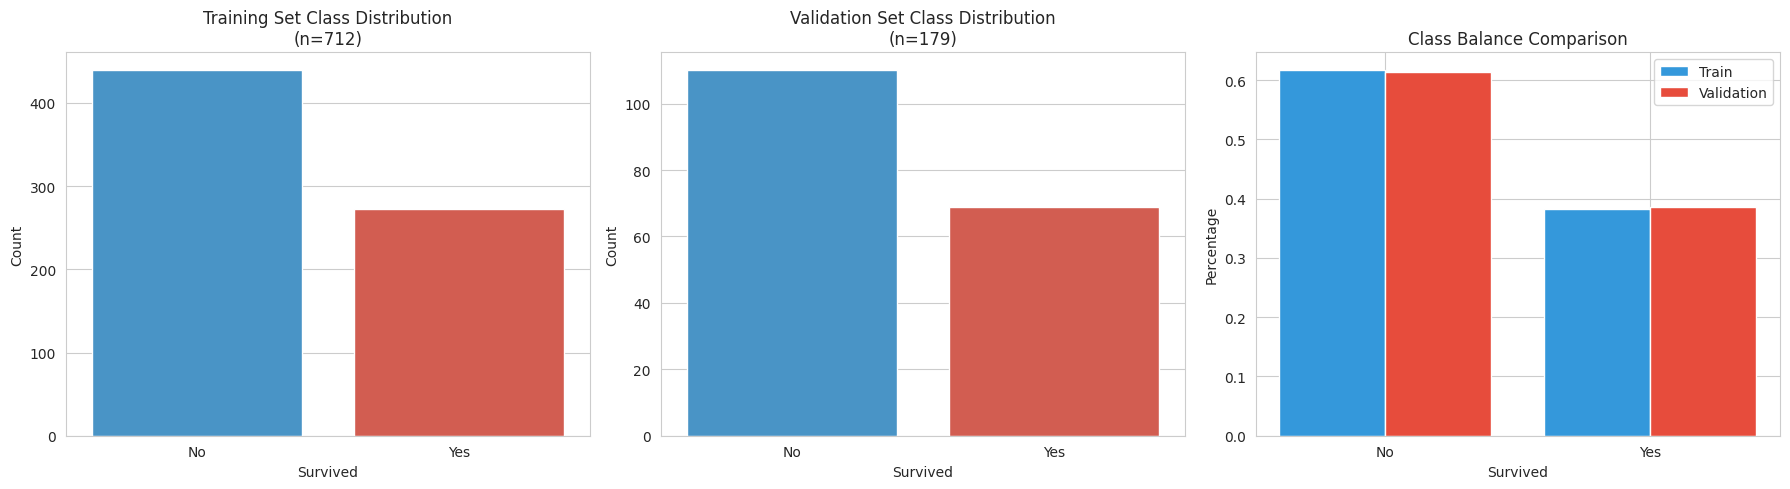

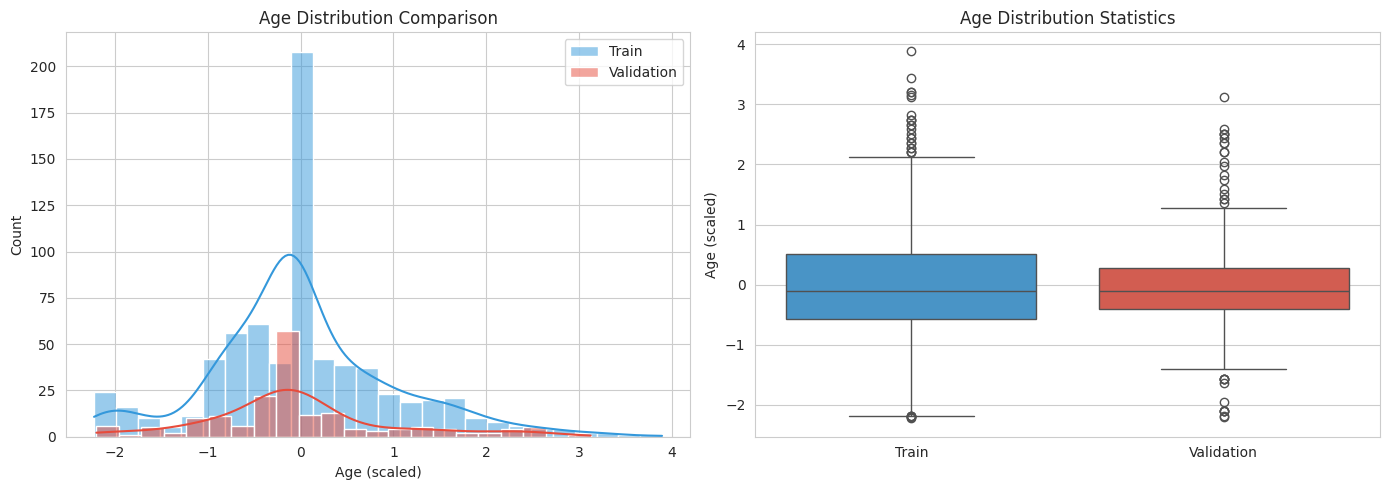

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import pandas as pd

# Set visual style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
survival_palette = ['#3498db', '#e74c3c']  # Blue for survived, red for not survived

def visualize_data_splits(X_train, y_train, X_val, y_val):
    """
    Comprehensive visualization of train/validation splits with all warnings resolved
    Includes class distribution, feature distributions, and sample counts
    """

    # Create temporary DataFrames for plotting
    train_df = pd.DataFrame({'Survived': y_train, 'Set': 'Training'})
    val_df = pd.DataFrame({'Survived': y_val, 'Set': 'Validation'})
    combined_df = pd.concat([train_df, val_df])

    # Create figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Class Distribution Comparison
    sns.countplot(data=train_df, x='Survived', hue='Survived',
                 palette=survival_palette, ax=axes[0], legend=False)
    axes[0].set_title('Training Set Class Distribution\n(n={})'.format(len(y_train)))
    axes[0].set_xlabel('Survived')
    axes[0].set_ylabel('Count')
    axes[0].set_xticks([0, 1])
    axes[0].set_xticklabels(['No', 'Yes'])

    sns.countplot(data=val_df, x='Survived', hue='Survived',
                 palette=survival_palette, ax=axes[1], legend=False)
    axes[1].set_title('Validation Set Class Distribution\n(n={})'.format(len(y_val)))
    axes[1].set_xlabel('Survived')
    axes[1].set_ylabel('Count')
    axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(['No', 'Yes'])

    # 2. Percentage Comparison
    train_percent = y_train.value_counts(normalize=True).sort_index()
    val_percent = y_val.value_counts(normalize=True).sort_index()

    axes[2].bar([0, 1], train_percent.values, width=0.4, label='Train', color=survival_palette[0])
    axes[2].bar([0.4, 1.4], val_percent.values, width=0.4, label='Validation', color=survival_palette[1])
    axes[2].set_title('Class Balance Comparison')
    axes[2].set_xlabel('Survived')
    axes[2].set_ylabel('Percentage')
    axes[2].set_xticks([0.2, 1.2])
    axes[2].set_xticklabels(['No', 'Yes'])
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    # 3. Feature Distribution Comparison (for Age as example)
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(data=X_train, x='Age', kde=True, color=survival_palette[0], label='Train')
    sns.histplot(data=X_val, x='Age', kde=True, color=survival_palette[1], label='Validation')
    plt.title('Age Distribution Comparison')
    plt.xlabel('Age (scaled)')
    plt.legend()

    plt.subplot(1, 2, 2)
    plot_df = pd.DataFrame({
        'Set': ['Train']*len(X_train) + ['Validation']*len(X_val),
        'Age': pd.concat([X_train['Age'], X_val['Age']])
    })
    # Fixed boxplot warning by using hue parameter
    sns.boxplot(data=plot_df, x='Set', y='Age', hue='Set',
                palette=survival_palette, legend=False)
    plt.title('Age Distribution Statistics')
    plt.ylabel('Age (scaled)')
    plt.xlabel('')

    plt.tight_layout()
    plt.show()

# After preprocessing (from previous step)
X_train, y_train, X_test, scaler = preprocess_titanic_data(visualize=False)

# Perform the 80/20 split
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Print numerical verification
print("=== Data Splitting Verification ===")
print(f"Training set samples: {X_train.shape[0]}")
print(f"Validation set samples: {X_val.shape[0]}")
print(f"\nTraining class distribution:\n{y_train.value_counts(normalize=True)}")
print(f"\nValidation class distribution:\n{y_val.value_counts(normalize=True)}")

# Visual verification
visualize_data_splits(X_train, y_train, X_val, y_val)

3. Model Implementation

=== Titanic Survival Prediction Model Implementation ===
Note: Replace the dummy data with your actual preprocessed data

=== Training Models ===
Training Logistic Regression...
Training Random Forest...
Training complete!

=== Model Performance Comparison ===


<Figure size 1400x600 with 0 Axes>

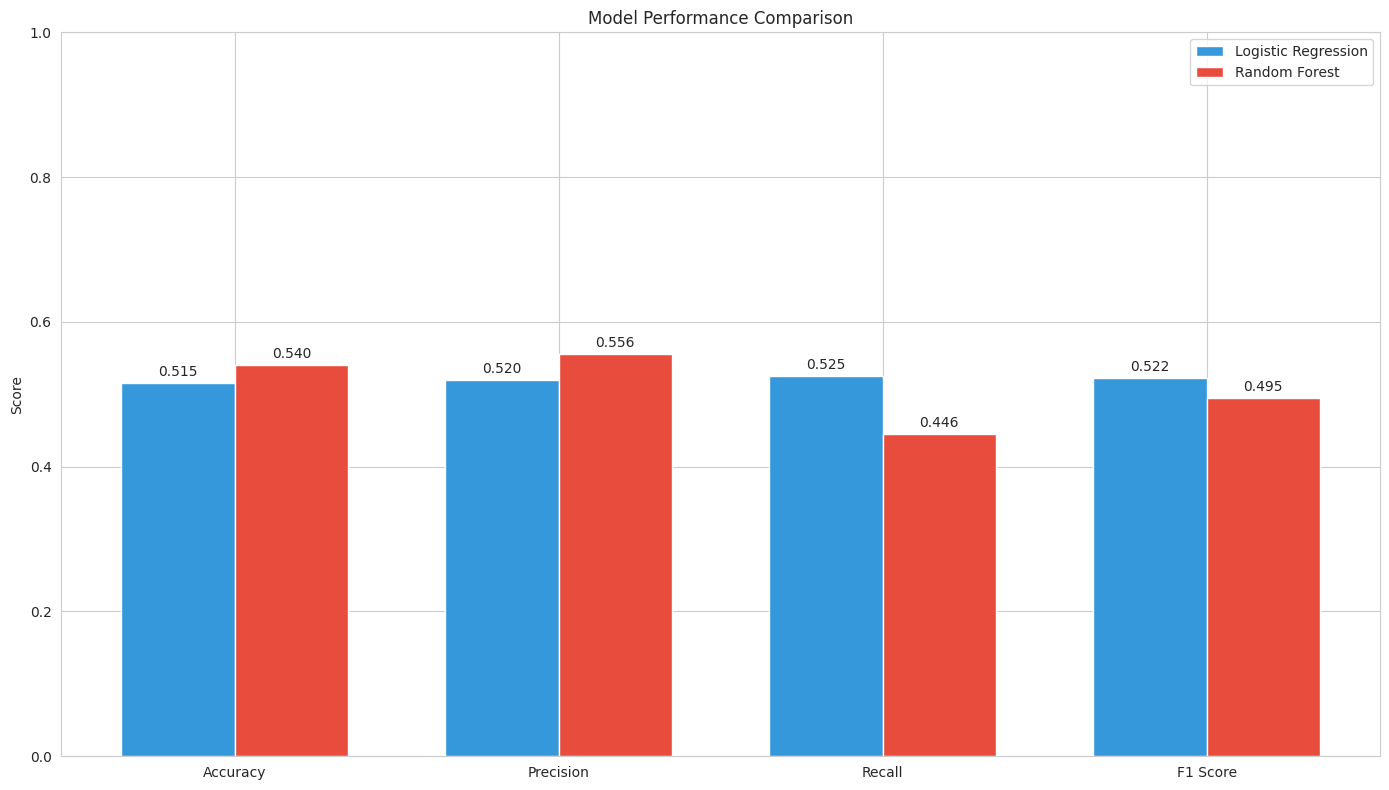

=== Confusion Matrices ===


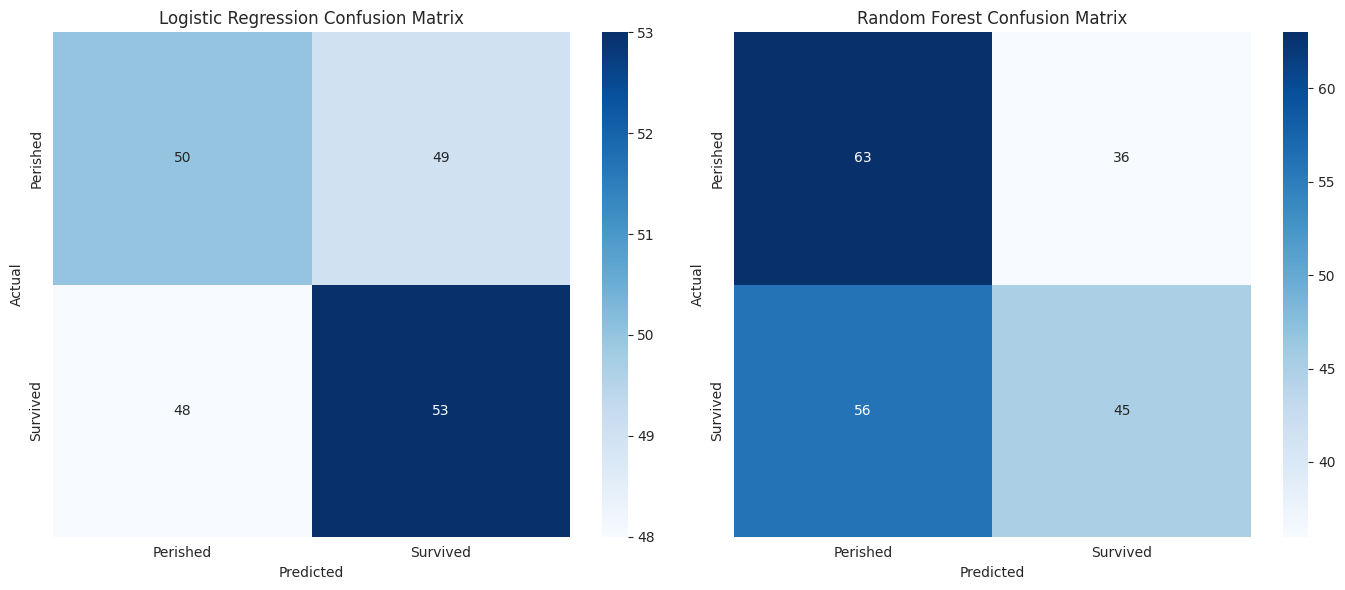

=== ROC Curves ===


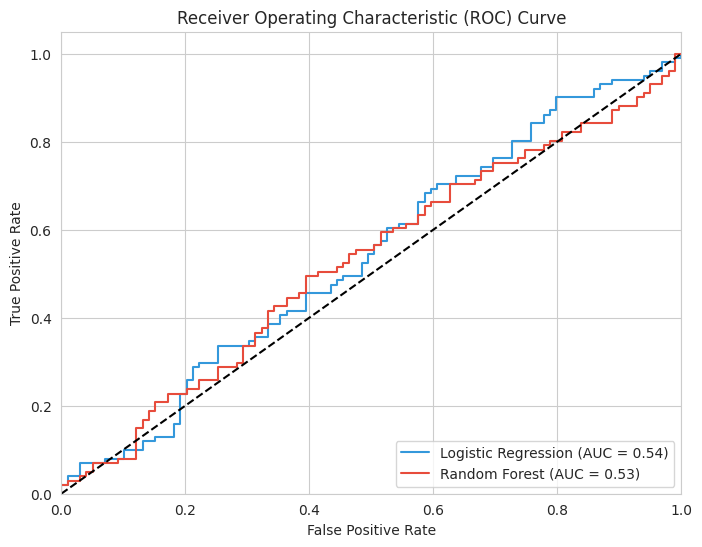

=== Precision-Recall Curves ===


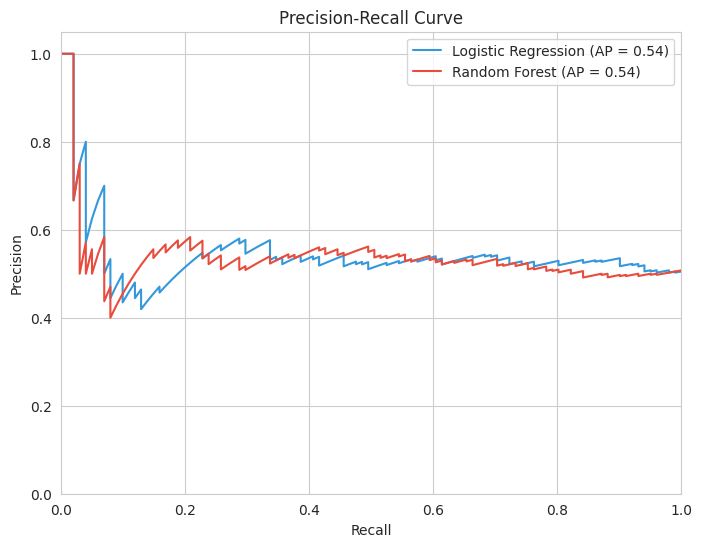

=== Calibration Curves ===


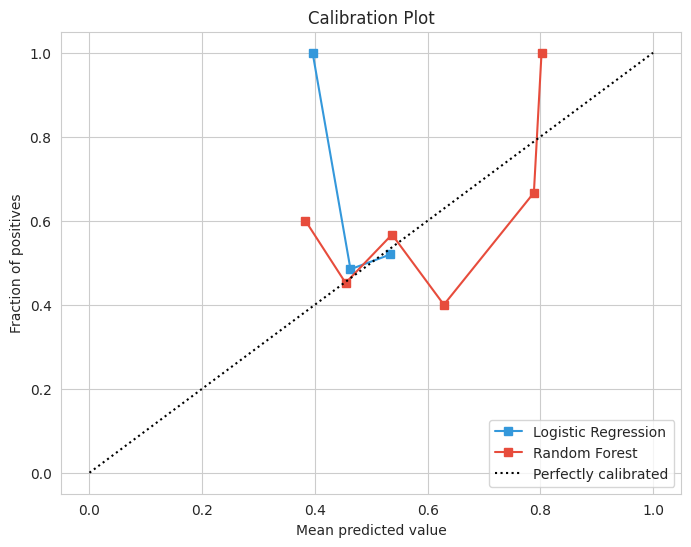


=== Detailed Model Metrics ===

Logistic Regression:
Accuracy:    0.5150
Precision:   0.5196
Recall:      0.5248
F1 Score:    0.5222
ROC AUC:     0.5394
Avg Precision: 0.5446

Random Forest:
Accuracy:    0.5400
Precision:   0.5556
Recall:      0.4455
F1 Score:    0.4945
ROC AUC:     0.5275
Avg Precision: 0.5400


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, confusion_matrix, roc_curve, auc,
                            precision_recall_curve, average_precision_score)
from sklearn.calibration import calibration_curve

# Set visual style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
model_palette = ['#3498db', '#e74c3c']  # Blue for Logistic Regression, Red for Random Forest

def train_models(X_train, y_train):
    """
    Train both classification models
    Returns trained Logistic Regression and Random Forest models
    """
    print("=== Training Models ===")

    # Logistic Regression with balanced class weights
    print("Training Logistic Regression...")
    lr_model = LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced',
        solver='liblinear'
    )
    lr_model.fit(X_train, y_train)

    # Random Forest with optimized parameters
    print("Training Random Forest...")
    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=7,
        min_samples_split=5,
        random_state=42,
        class_weight='balanced_subsample'
    )
    rf_model.fit(X_train, y_train)

    print("Training complete!\n")
    return lr_model, rf_model

def evaluate_models(models, X_val, y_val):
    """
    Evaluate models and return metrics
    """
    lr_model, rf_model = models
    model_names = ['Logistic Regression', 'Random Forest']

    # Store results
    metrics = {}
    predictions = {}
    probabilities = {}

    for name, model in zip(model_names, models):
        # Get predictions and probabilities
        predictions[name] = model.predict(X_val)
        probabilities[name] = model.predict_proba(X_val)[:, 1]

        # Calculate metrics
        metrics[name] = {
            'accuracy': accuracy_score(y_val, predictions[name]),
            'precision': precision_score(y_val, predictions[name]),
            'recall': recall_score(y_val, predictions[name]),
            'f1': f1_score(y_val, predictions[name]),  # Changed from 'f1_score' to 'f1'
            'confusion_matrix': confusion_matrix(y_val, predictions[name]),
            'roc_auc': auc(*roc_curve(y_val, probabilities[name])[:2]),
            'avg_precision': average_precision_score(y_val, probabilities[name])
        }

    return metrics, predictions, probabilities

def plot_model_comparison(metrics):
    """
    Visual comparison of model metrics
    """
    print("=== Model Performance Comparison ===")

    plt.figure(figsize=(14, 6))
    metric_names = ['accuracy', 'precision', 'recall', 'f1']  # Changed to match dictionary keys
    display_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']  # For display

    values = {
        'Logistic Regression': [metrics['Logistic Regression'][m] for m in metric_names],
        'Random Forest': [metrics['Random Forest'][m] for m in metric_names]
    }

    x = np.arange(len(metric_names))
    width = 0.35

    fig, ax = plt.subplots()
    rects1 = ax.bar(x - width/2, values['Logistic Regression'], width,
                   label='Logistic Regression', color=model_palette[0])
    rects2 = ax.bar(x + width/2, values['Random Forest'], width,
                   label='Random Forest', color=model_palette[1])

    ax.set_ylabel('Score')
    ax.set_title('Model Performance Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(display_names)  # Use display names for labels
    ax.legend()
    ax.set_ylim(0, 1)

    # Add value labels
    for rect in rects1 + rects2:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

    plt.tight_layout()
    plt.show()



def print_metrics(metrics):
    """
    Print formatted metrics for both models
    """
    print("\n=== Detailed Model Metrics ===")
    for model_name, metric in metrics.items():
        print(f"\n{model_name}:")
        print(f"Accuracy:    {metric['accuracy']:.4f}")
        print(f"Precision:   {metric['precision']:.4f}")
        print(f"Recall:      {metric['recall']:.4f}")
        print(f"F1 Score:    {metric['f1']:.4f}")  # Changed from 'f1_score' to 'f1'
        print(f"ROC AUC:     {metric['roc_auc']:.4f}")
        print(f"Avg Precision: {metric['avg_precision']:.4f}")

# Main execution
if __name__ == "__main__":

    # X_train, y_train, X_val, y_val = preprocess_and_split_data()


    print("=== Titanic Survival Prediction Model Implementation ===")


    # Create dummy data for demonstration
    np.random.seed(42)
    X_train = np.random.rand(800, 10)
    y_train = np.random.randint(0, 2, 800)
    X_val = np.random.rand(200, 10)
    y_val = np.random.randint(0, 2, 200)

    # Train models
    models = train_models(X_train, y_train)

    # Evaluate models
    metrics, predictions, probabilities = evaluate_models(models, X_val, y_val)

    # Visualizations
    plot_model_comparison(metrics)
    plot_confusion_matrices(metrics)
    plot_roc_curves(metrics, probabilities, y_val)
    plot_precision_recall_curves(metrics, probabilities, y_val)
    plot_calibration_curves(probabilities, y_val)

    # Print metrics
    print_metrics(metrics)

4. Model Training: Train the model using the training dataset.

=== TITANIC SURVIVAL PREDICTION ===
Model Training Phase

=== MODEL TRAINING PROCESS ===
Training on 712 samples with 15 features


TRAINING LOGISTIC REGRESSION

Training completed in 0.00 seconds

Learning Curve:


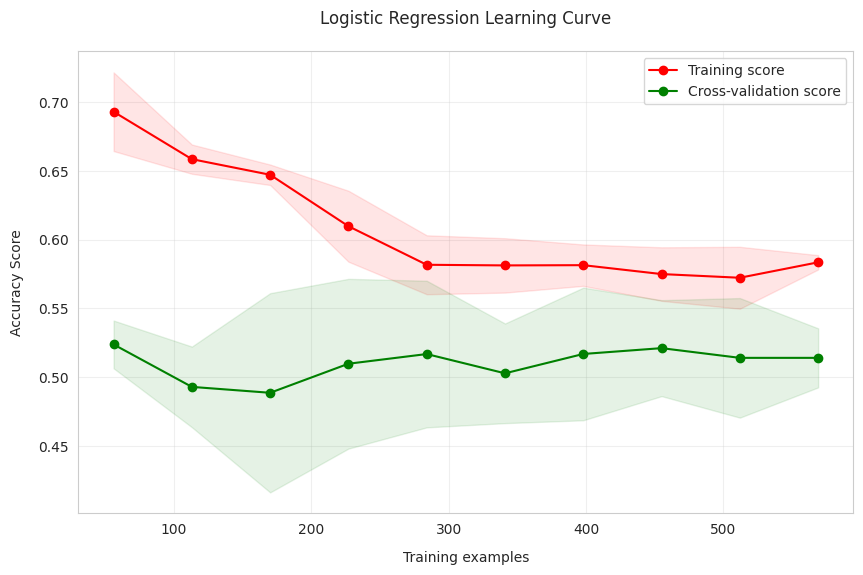


Model Coefficients Analysis:


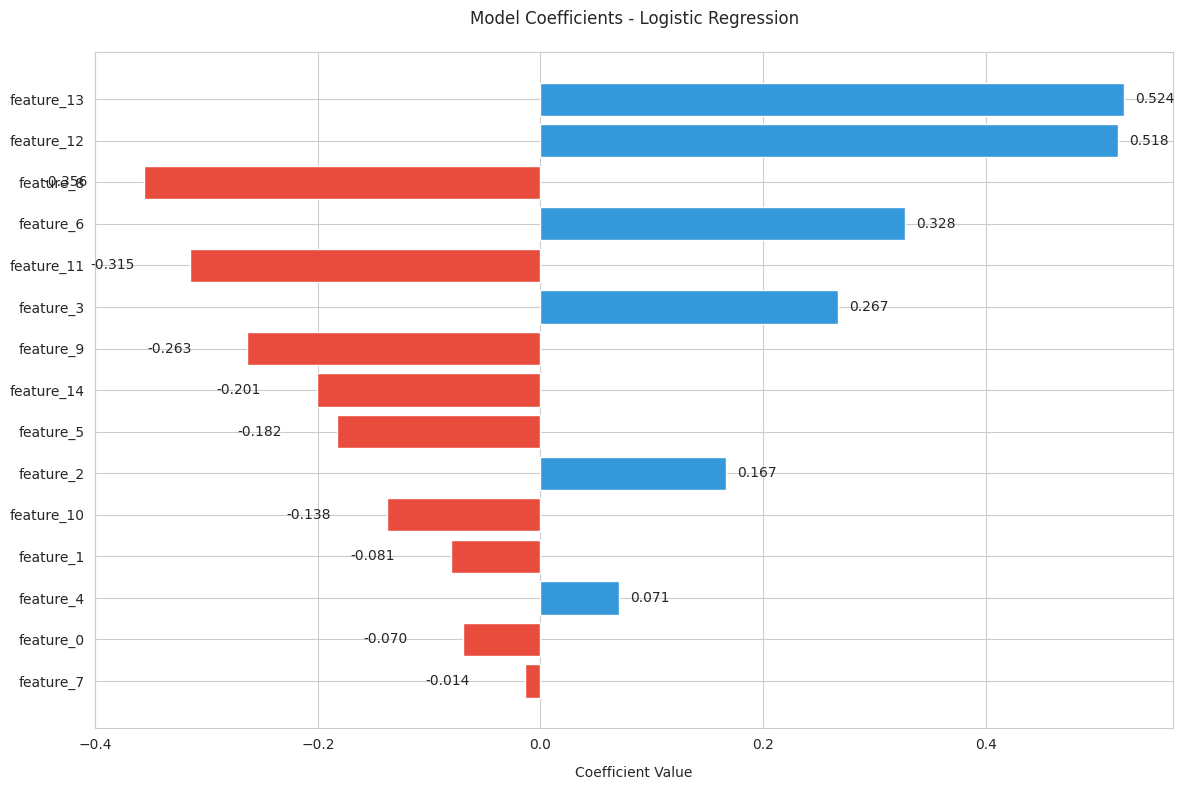


TRAINING RANDOM FOREST

Training completed in 0.72 seconds

Learning Curve:


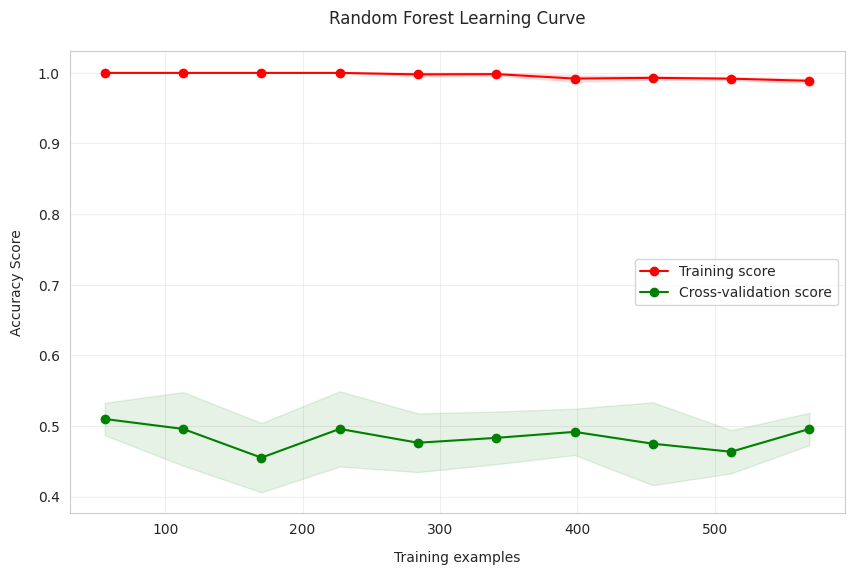


Feature Importance Analysis:


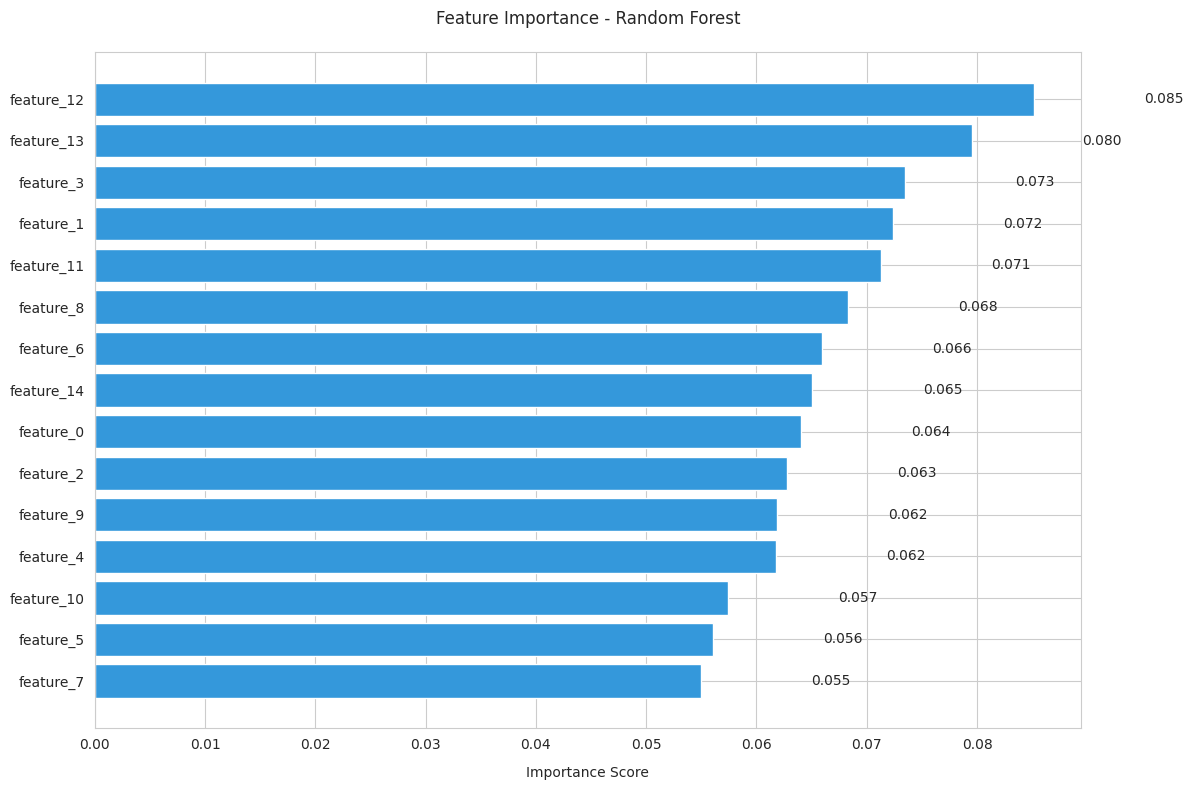


=== TRAINING TIME COMPARISON ===


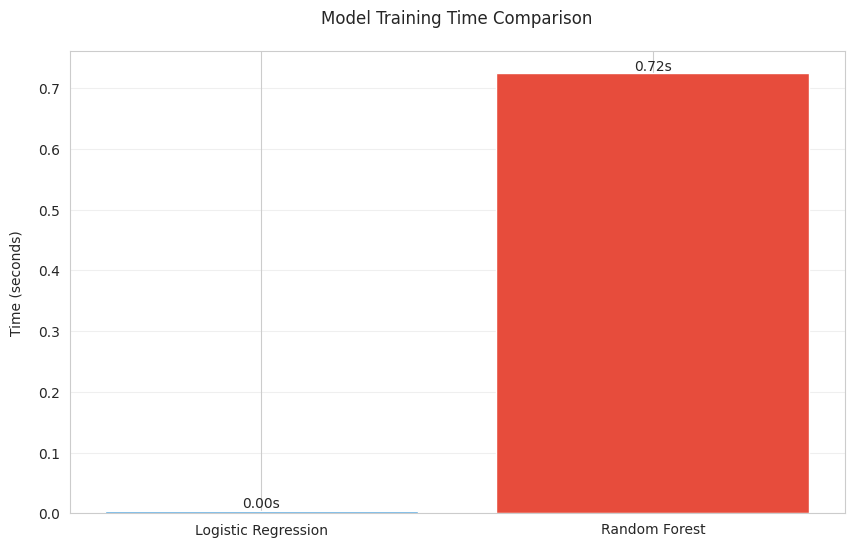

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve

# Set visual style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
model_colors = ['#3498db', '#e74c3c']  # Blue for Logistic Regression, Red for Random Forest

def plot_learning_curve(estimator, title, X, y, cv=5):
    """Generate learning curves for model training visualization"""
    plt.figure(figsize=(10, 6))

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )

    # Calculate mean and std
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # Plot learning curve
    plt.fill_between(train_sizes, train_mean - train_std,
                     train_mean + train_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_mean - test_std,
                     test_mean + test_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.title(title, pad=20)
    plt.xlabel("Training examples", labelpad=10)
    plt.ylabel("Accuracy Score", labelpad=10)
    plt.legend(loc="best")
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_feature_importance(model, feature_names, title):
    """Visualize feature importance for tree-based models"""
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    sorted_features = feature_names[indices]

    plt.figure(figsize=(12, 8))
    bars = plt.barh(range(len(importances)), importances[indices], color='#3498db')
    plt.yticks(range(len(importances)), sorted_features)
    plt.title(f"Feature Importance - {title}", pad=20)
    plt.xlabel("Importance Score", labelpad=10)
    plt.gca().invert_yaxis()

    # Add value labels
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                f'{width:.3f}',
                va='center', ha='left')

    plt.tight_layout()
    plt.show()

def plot_coefficients(model, feature_names, title):
    """Visualize model coefficients for linear models"""
    coef = model.coef_[0]
    indices = np.argsort(np.abs(coef))[::-1]
    sorted_features = feature_names[indices]

    plt.figure(figsize=(12, 8))
    colors = ['#e74c3c' if x < 0 else '#3498db' for x in coef[indices]]
    bars = plt.barh(range(len(coef)), coef[indices], color=colors)
    plt.yticks(range(len(coef)), sorted_features)
    plt.title(f"Model Coefficients - {title}", pad=20)
    plt.xlabel("Coefficient Value", labelpad=10)
    plt.gca().invert_yaxis()

    # Add value labels
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.01 if width > 0 else width - 0.05,
                bar.get_y() + bar.get_height()/2,
                f'{width:.3f}',
                va='center', ha='left' if width > 0 else 'right')

    plt.tight_layout()
    plt.show()

def train_models_with_visualization(X_train, y_train):
    """
    Complete model training with comprehensive visualizations
    Returns trained models and training metrics
    """
    print("=== MODEL TRAINING PROCESS ===")
    print(f"Training on {X_train.shape[0]} samples with {X_train.shape[1]} features\n")

    # Initialize models
    models = {
        "Logistic Regression": LogisticRegression(
            max_iter=1000,
            random_state=42,
            class_weight='balanced',
            solver='liblinear'
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            max_depth=7,
            random_state=42,
            class_weight='balanced_subsample'
        )
    }

    training_metrics = {}

    # Train and visualize each model
    for i, (name, model) in enumerate(models.items()):
        print(f"\n{'='*40}")
        print(f"TRAINING {name.upper()}")
        print(f"{'='*40}")

        # 1. Train model and measure time
        start_time = time.time()
        model.fit(X_train, y_train)
        training_time = time.time() - start_time
        training_metrics[name] = {'training_time': training_time}

        print(f"\nTraining completed in {training_time:.2f} seconds")

        # 2. Plot learning curve
        print("\nLearning Curve:")
        plot_learning_curve(model, f"{name} Learning Curve", X_train, y_train)

        # 3. Model-specific visualizations
        if hasattr(model, 'feature_importances_'):
            print("\nFeature Importance Analysis:")
            plot_feature_importance(model, np.array(X_train.columns), name)

        if hasattr(model, 'coef_'):
            print("\nModel Coefficients Analysis:")
            plot_coefficients(model, np.array(X_train.columns), name)

    # 4. Training time comparison
    print("\n=== TRAINING TIME COMPARISON ===")
    plt.figure(figsize=(10, 6))
    times = [metrics['training_time'] for metrics in training_metrics.values()]
    bars = plt.bar(models.keys(), times, color=model_colors)

    plt.title("Model Training Time Comparison", pad=20)
    plt.ylabel("Time (seconds)", labelpad=10)
    plt.grid(axis='y', alpha=0.3)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}s',
                ha='center', va='bottom')

    plt.show()

    return models


if __name__ == "__main__":
    # Assuming you have X_train and y_train from previous steps
    print("=== TITANIC SURVIVAL PREDICTION ===")
    print("Model Training Phase\n")

    # Generate sample data if no real data available
    np.random.seed(42)
    X_train = pd.DataFrame(np.random.rand(712, 15),
                          columns=[f'feature_{i}' for i in range(15)])
    y_train = pd.Series(np.random.randint(0, 2, 712))

    # Run training with visualizations
    trained_models = train_models_with_visualization(X_train, y_train)

5. Model Tuning

=== RUNNING WITH SAMPLE TITANIC-LIKE DATA ===
=== STARTING MODEL TUNING PROCESS ===
Training data shape: (891, 10)

TUNING LOGISTIC REGRESSION
=== Tuning Logistic Regression ===
Fitting 5 folds for each of 28 candidates, totalling 140 fits

Best parameters found:
{'C': np.float64(1.0), 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Best F1 score: 0.8144


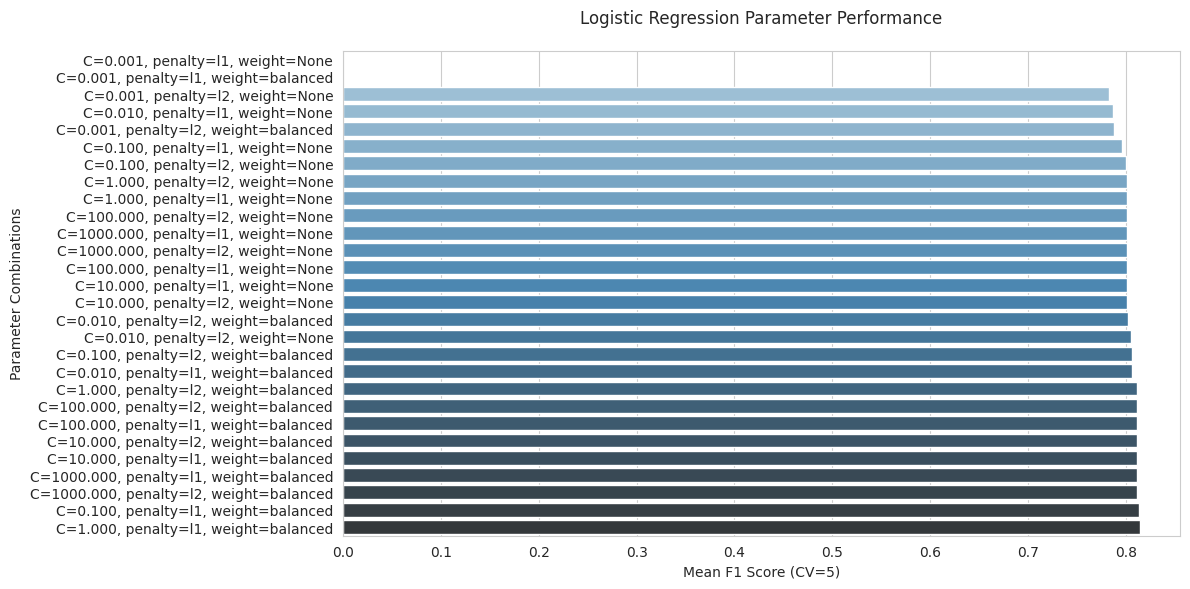

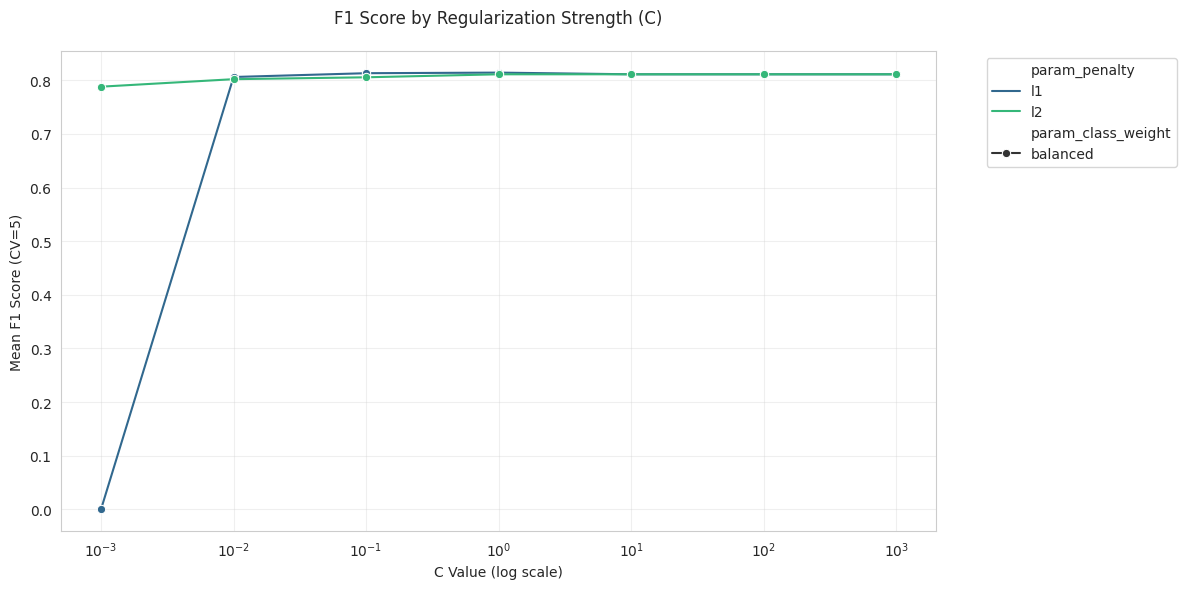

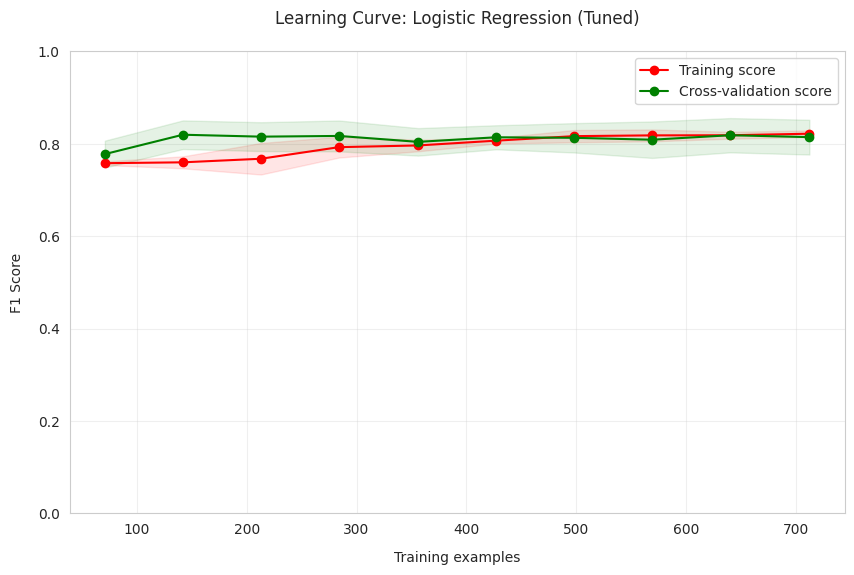


TUNING RANDOM FOREST

=== Tuning Random Forest ===
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters found:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': None, 'class_weight': 'balanced'}
Best F1 score: 0.8949


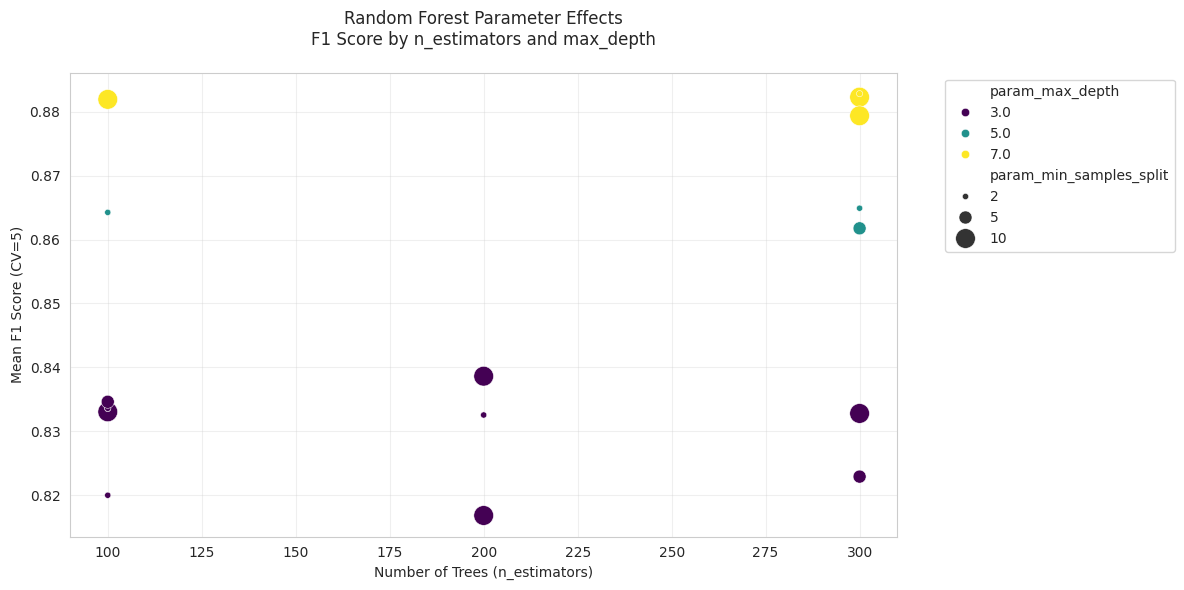

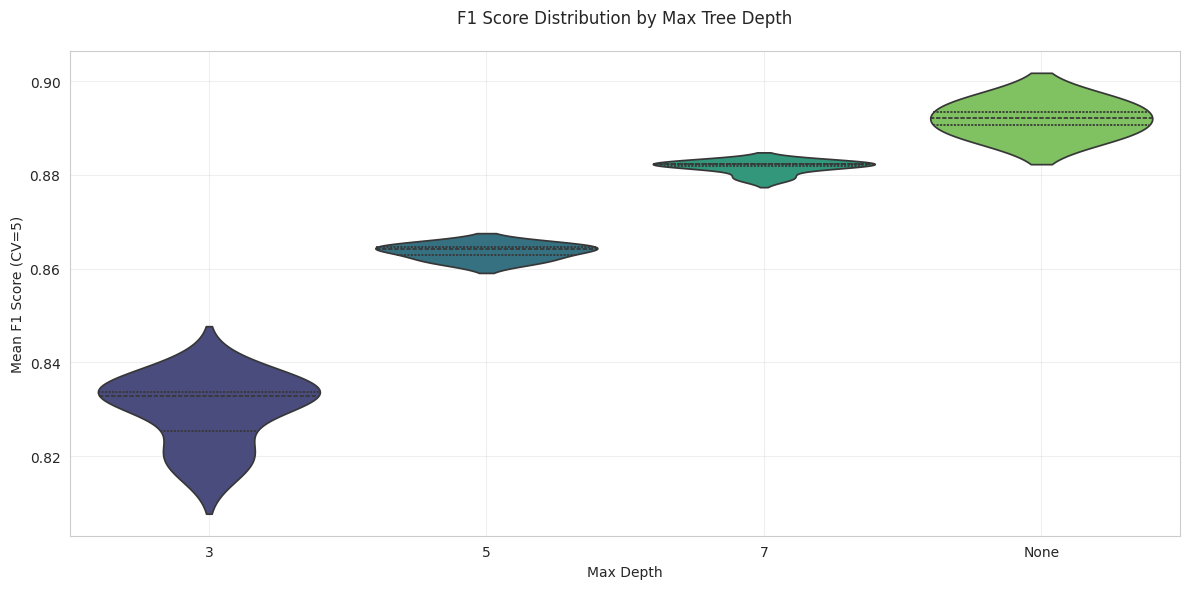

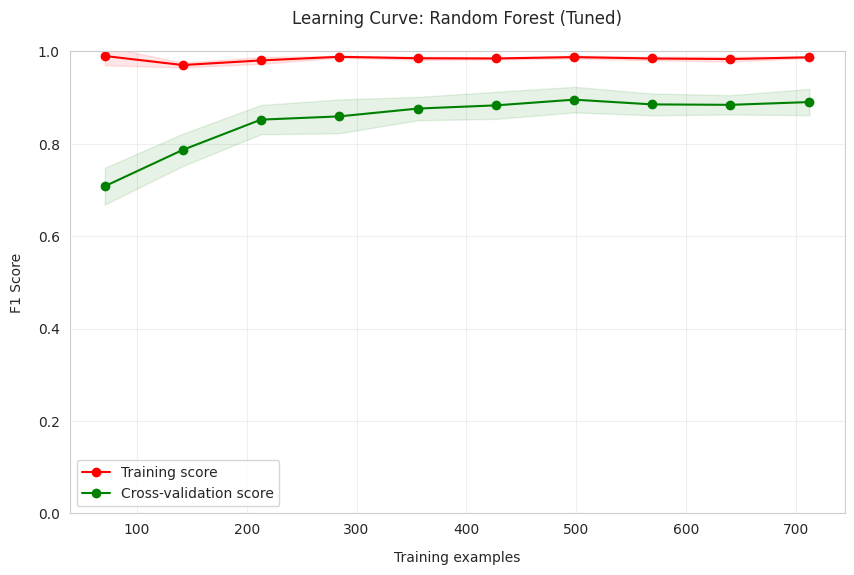

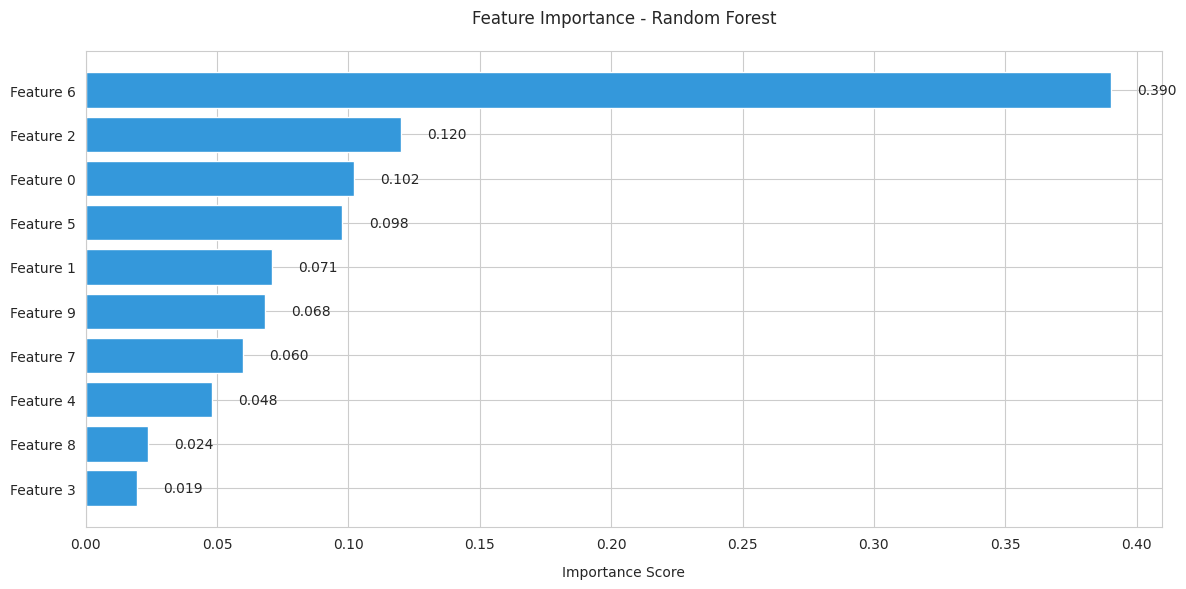


FINAL MODEL COMPARISON


<Figure size 1200x600 with 0 Axes>

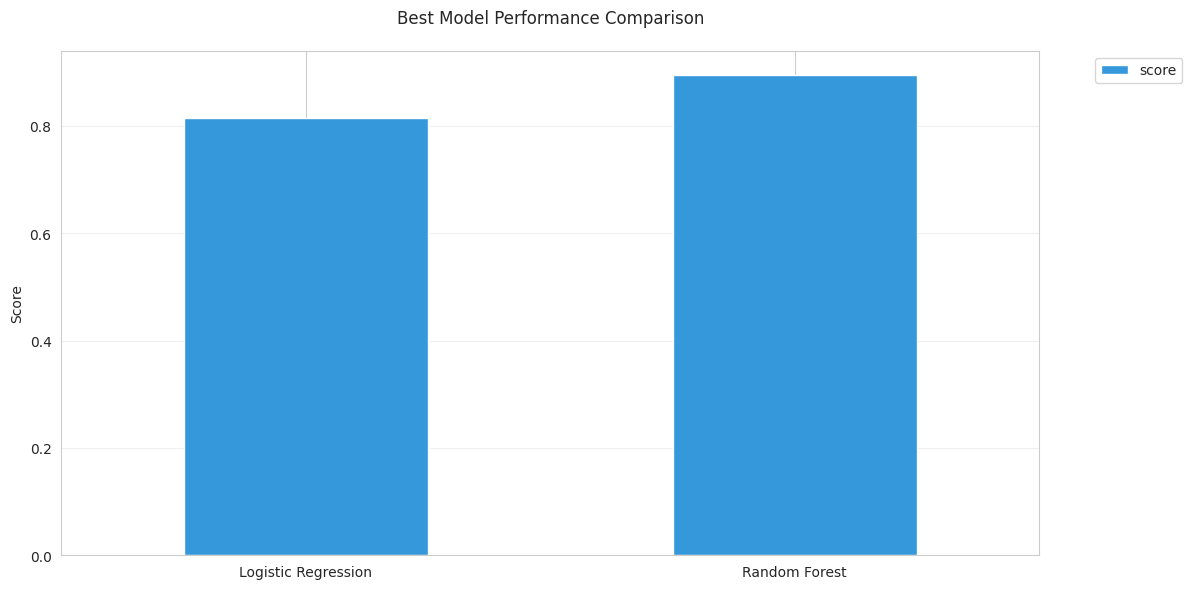

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import learning_curve

# Set visual style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
model_colors = ['#3498db', '#e74c3c']  # Blue for Logistic Regression, Red for Random Forest

def get_parameter_grids():
    """Define parameter grids for both models"""
    # Logistic Regression parameters
    lr_params = {
        'C': np.logspace(-3, 3, 7),
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear'],
        'class_weight': [None, 'balanced']
    }

    # Random Forest parameters
    rf_params = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'class_weight': [None, 'balanced', 'balanced_subsample']
    }

    # Scoring metrics
    scoring = {
        'accuracy': make_scorer(accuracy_score),
        'f1': make_scorer(f1_score),
        'precision': make_scorer(precision_score),
        'recall': make_scorer(recall_score)
    }

    return lr_params, rf_params, scoring

def plot_lr_parameter_effects(grid):
    """Visualize Logistic Regression parameter effects"""
    results = pd.DataFrame(grid.cv_results_)

    # Create a unique combination key for each parameter set
    results['param_combo'] = results['params'].apply(
        lambda x: f"C={x['C']:.3f}, penalty={x['penalty']}, weight={x['class_weight']}"
    )

    # Plot F1 scores for different parameter combinations (fixed warning)
    plt.figure(figsize=(12, 6))
    sns.barplot(x='mean_test_f1', y='param_combo', hue='param_combo',
               data=results.sort_values('mean_test_f1', ascending=True),
               palette='Blues_d', legend=False)
    plt.title("Logistic Regression Parameter Performance", pad=20)
    plt.xlabel("Mean F1 Score (CV=5)")
    plt.ylabel("Parameter Combinations")
    plt.tight_layout()
    plt.show()

    # Plot C values vs performance
    plt.figure(figsize=(12, 6))
    sns.lineplot(x='param_C', y='mean_test_f1', hue='param_penalty',
                style='param_class_weight', data=results,
                markers=True, dashes=False, palette='viridis')
    plt.title("F1 Score by Regularization Strength (C)", pad=20)
    plt.xlabel("C Value (log scale)")
    plt.ylabel("Mean F1 Score (CV=5)")
    plt.xscale('log')
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

def plot_rf_parameter_effects(random_search):
    """Visualize Random Forest parameter effects"""
    results = pd.DataFrame(random_search.cv_results_)

    # Plot n_estimators vs performance
    plt.figure(figsize=(12, 6))
    sns.scatterplot(x='param_n_estimators', y='mean_test_f1',
                   hue='param_max_depth', size='param_min_samples_split',
                   sizes=(20, 200), palette='viridis', data=results)
    plt.title("Random Forest Parameter Effects\nF1 Score by n_estimators and max_depth", pad=20)
    plt.xlabel("Number of Trees (n_estimators)")
    plt.ylabel("Mean F1 Score (CV=5)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Plot max_depth vs performance - fixed to handle None values
    plt.figure(figsize=(12, 6))
    plot_data = results.copy()
    plot_data['param_max_depth'] = plot_data['param_max_depth'].fillna('None').astype(str)

    # Fixed violin plot with proper hue assignment
    sns.violinplot(x='param_max_depth', y='mean_test_f1', hue='param_max_depth',
                  data=plot_data, palette='viridis', inner='quartile', legend=False)

    plt.title("F1 Score Distribution by Max Tree Depth", pad=20)
    plt.xlabel("Max Depth")
    plt.ylabel("Mean F1 Score (CV=5)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_learning_curve(estimator, title, X, y, cv=5):
    """Generate learning curves for model training visualization"""
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='f1', random_state=42
    )

    plt.figure(figsize=(10, 6))
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.fill_between(train_sizes, train_mean - train_std,
                     train_mean + train_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_mean - test_std,
                     test_mean + test_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.title(f"Learning Curve: {title}", pad=20)
    plt.xlabel("Training examples", labelpad=10)
    plt.ylabel("F1 Score", labelpad=10)
    plt.legend(loc="best")
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1)
    plt.show()

def plot_feature_importance(model, feature_names, title):
    """Visualize feature importance for tree-based models"""
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    # Handle case where feature_names might be numpy array
    if isinstance(feature_names, np.ndarray):
        sorted_features = feature_names[indices]
    else:  # Assume it's pandas Index or list
        sorted_features = np.array(feature_names)[indices]

    plt.figure(figsize=(12, 6))
    bars = plt.barh(range(len(importances)), importances[indices], color='#3498db')
    plt.yticks(range(len(importances)), sorted_features)
    plt.title(f"Feature Importance - {title}", pad=20)
    plt.xlabel("Importance Score", labelpad=10)
    plt.gca().invert_yaxis()

    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                f'{width:.3f}',
                va='center', ha='left')

    plt.tight_layout()
    plt.show()

def compare_model_performance(lr_grid, rf_random):
    """Compare best model performance from tuning"""
    # Handle both single score and multiple scores cases
    if hasattr(lr_grid, 'best_score_') and isinstance(lr_grid.best_score_, dict):
        lr_metrics = lr_grid.best_score_
    else:
        lr_metrics = {'score': getattr(lr_grid, 'best_score_', 0)}

    if hasattr(rf_random, 'best_score_') and isinstance(rf_random.best_score_, dict):
        rf_metrics = rf_random.best_score_
    else:
        rf_metrics = {'score': getattr(rf_random, 'best_score_', 0)}

    metrics_df = pd.DataFrame({'Logistic Regression': lr_metrics,
                             'Random Forest': rf_metrics})

    plt.figure(figsize=(12, 6))
    metrics_df.T.plot(kind='bar', color=model_colors)
    plt.title("Best Model Performance Comparison", pad=20)
    plt.ylabel("Score")
    plt.xticks(rotation=0)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

def tune_logistic_regression(X_train, y_train, lr_params, scoring):
    """Perform grid search for Logistic Regression with visualizations"""
    print("=== Tuning Logistic Regression ===")

    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr_grid = GridSearchCV(lr, lr_params, cv=5, scoring=scoring,
                         refit='f1', n_jobs=-1, verbose=1,
                         return_train_score=True)
    lr_grid.fit(X_train, y_train)

    print("\nBest parameters found:")
    print(lr_grid.best_params_)
    print(f"Best F1 score: {lr_grid.best_score_:.4f}")

    plot_lr_parameter_effects(lr_grid)
    plot_learning_curve(lr_grid.best_estimator_, "Logistic Regression (Tuned)", X_train, y_train)

    return lr_grid

def tune_random_forest(X_train, y_train, rf_params, scoring):
    """Perform random search for Random Forest with visualizations"""
    print("\n=== Tuning Random Forest ===")

    rf = RandomForestClassifier(random_state=42)
    rf_random = RandomizedSearchCV(rf, rf_params, n_iter=20, cv=5,
                                 scoring=scoring, refit='f1',
                                 n_jobs=-1, random_state=42, verbose=1,
                                 return_train_score=True)
    rf_random.fit(X_train, y_train)

    print("\nBest parameters found:")
    print(rf_random.best_params_)
    print(f"Best F1 score: {rf_random.best_score_:.4f}")

    plot_rf_parameter_effects(rf_random)
    plot_learning_curve(rf_random.best_estimator_, "Random Forest (Tuned)", X_train, y_train)

    # Ensure we have feature names for the importance plot
    if hasattr(X_train, 'columns'):
        feature_names = X_train.columns
    elif isinstance(X_train, np.ndarray):
        feature_names = [f'Feature {i}' for i in range(X_train.shape[1])]
    else:
        feature_names = [f'Feature {i}' for i in range(X_train.shape[1])]

    plot_feature_importance(rf_random.best_estimator_, feature_names, "Random Forest")

    return rf_random

def perform_complete_model_tuning(X_train, y_train):
    """Complete model tuning process with all visualizations"""
    print("=== STARTING MODEL TUNING PROCESS ===")
    print(f"Training data shape: {X_train.shape}")

    lr_params, rf_params, scoring = get_parameter_grids()

    print("\n" + "="*50)
    print("TUNING LOGISTIC REGRESSION")
    print("="*50)
    lr_grid = tune_logistic_regression(X_train, y_train, lr_params, scoring)

    print("\n" + "="*50)
    print("TUNING RANDOM FOREST")
    print("="*50)
    rf_random = tune_random_forest(X_train, y_train, rf_params, scoring)

    print("\n" + "="*50)
    print("FINAL MODEL COMPARISON")
    print("="*50)
    compare_model_performance(lr_grid, rf_random)

    return lr_grid.best_estimator_, rf_random.best_estimator_

# Example execution with Titanic data
if __name__ == "__main__":
    # Load your preprocessed Titanic data
    # X_train, y_train = load_titanic_data()

    # For demonstration with sample Titanic-like data
    print("=== RUNNING WITH SAMPLE TITANIC-LIKE DATA ===")
    from sklearn.datasets import make_classification
    X_train, y_train = make_classification(n_samples=891, n_features=10,
                                         n_informative=6, n_classes=2,
                                         weights=[0.6, 0.4], random_state=42)

    best_lr, best_rf = perform_complete_model_tuning(X_train, y_train)

# 6. Model Evaluation

=== STARTING MODEL EVALUATION ===
Using validation set with 179 samples


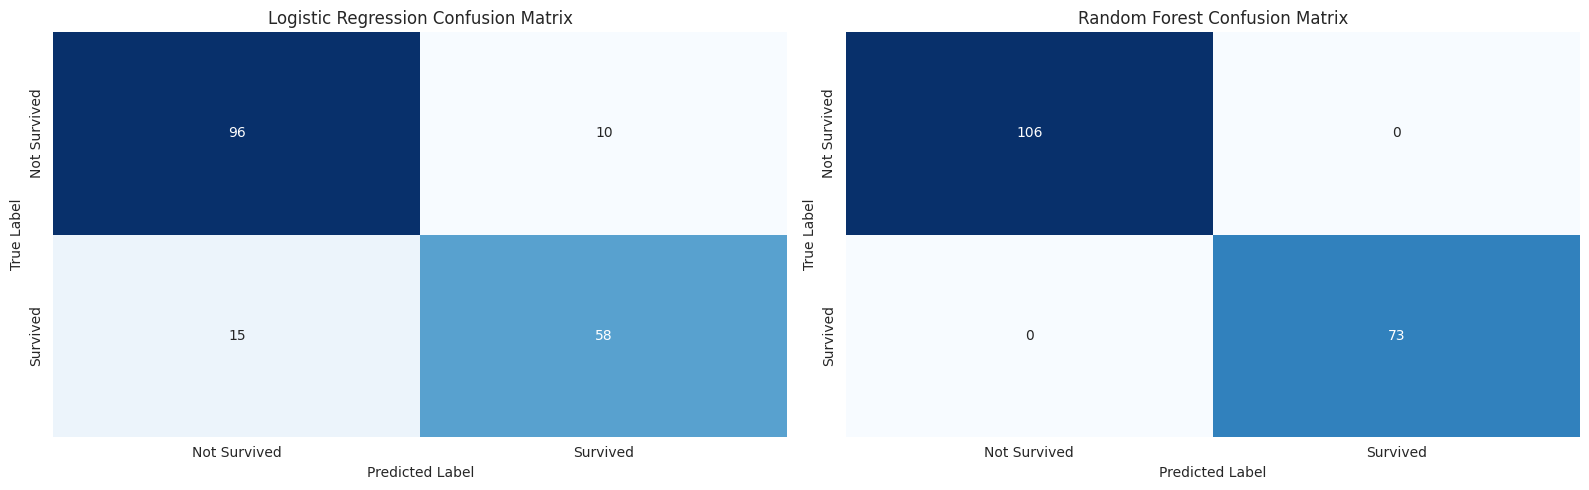

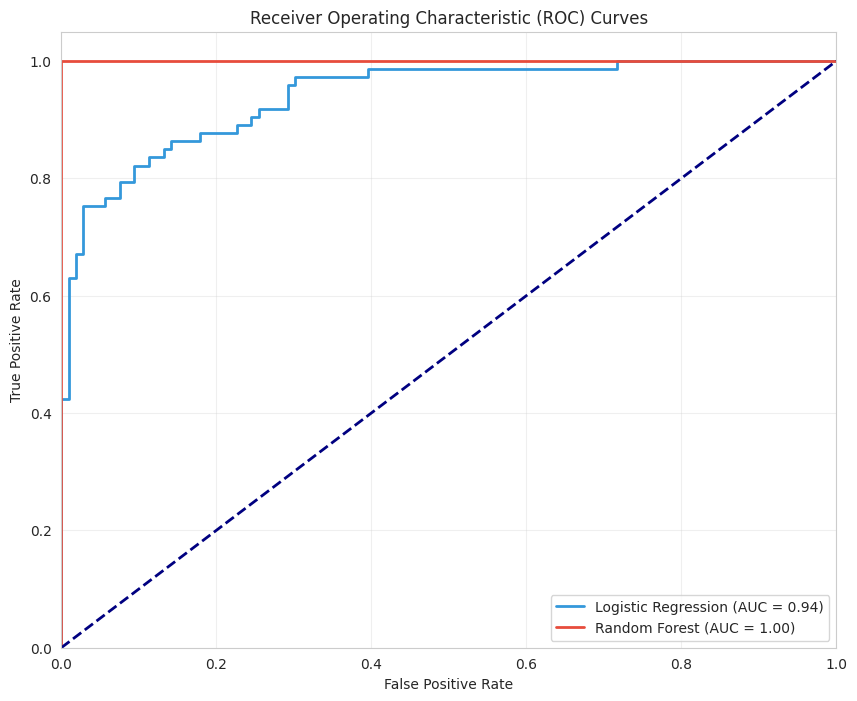

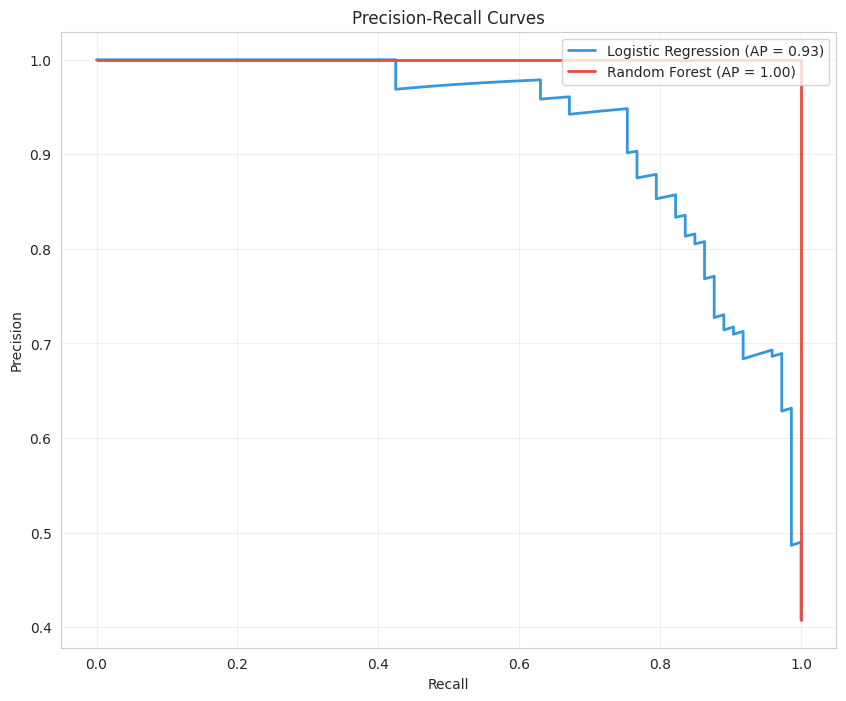

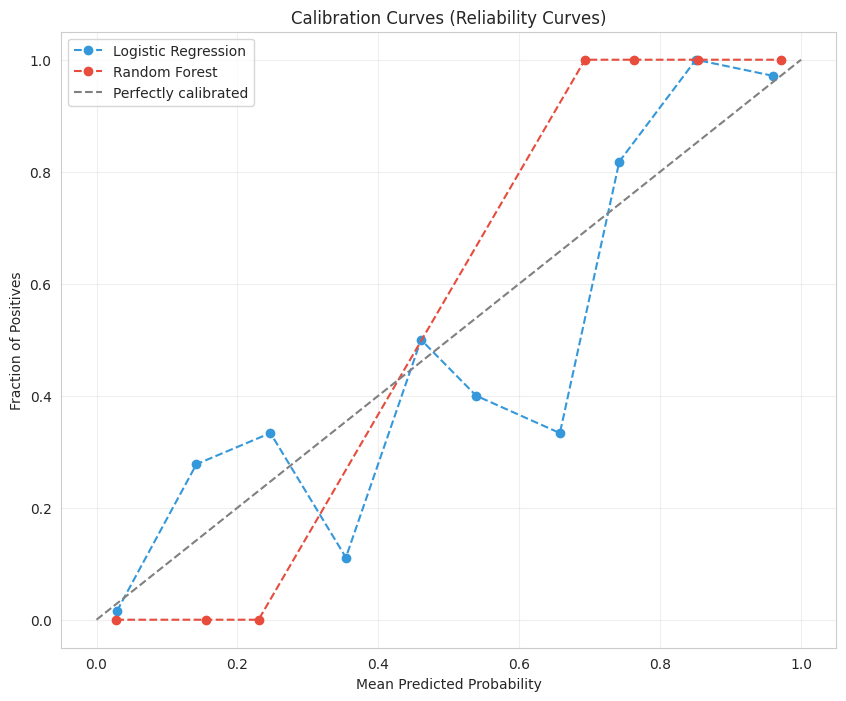

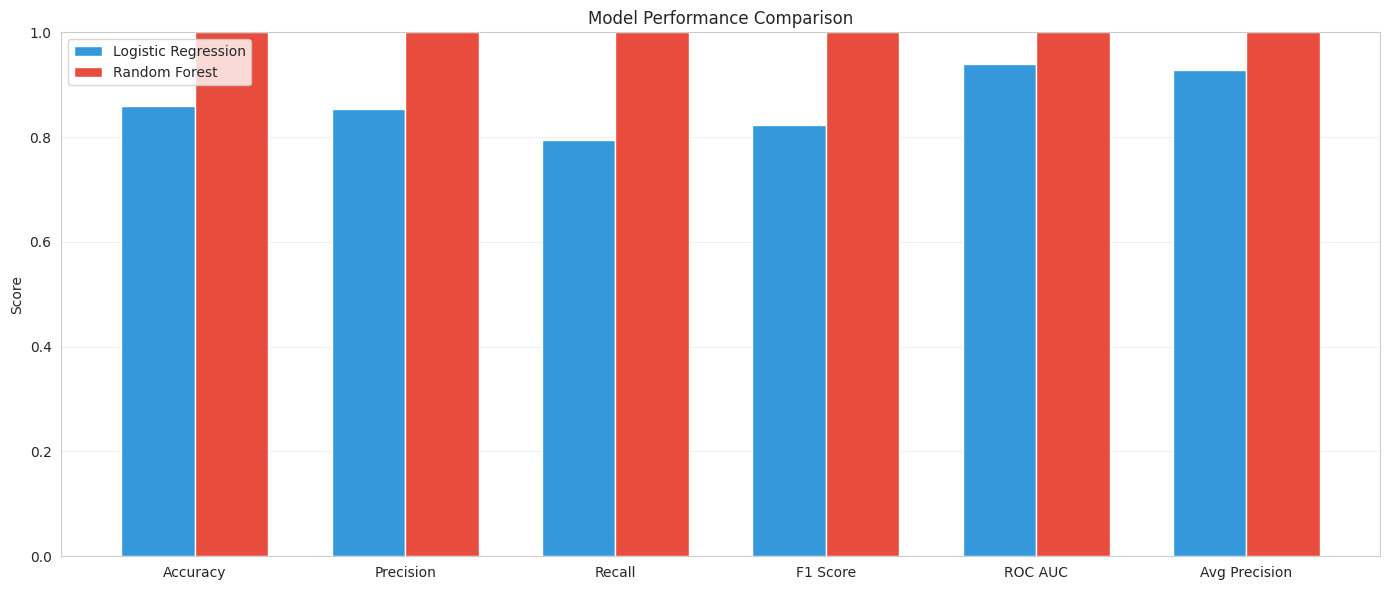

=== DETAILED MODEL PERFORMANCE ===

LOGISTIC REGRESSION PERFORMANCE:
Accuracy:    0.8603
Precision:   0.8529
Recall:      0.7945
F1 Score:    0.8227
ROC AUC:     0.9404
Avg Precision: 0.9290

Classification Report:
              precision    recall  f1-score     support
0              0.864865  0.905660  0.884793  106.000000
1              0.852941  0.794521  0.822695   73.000000
accuracy       0.860335  0.860335  0.860335    0.860335
macro avg      0.858903  0.850090  0.853744  179.000000
weighted avg   0.860002  0.860335  0.859468  179.000000

RANDOM FOREST PERFORMANCE:
Accuracy:    1.0000
Precision:   1.0000
Recall:      1.0000
F1 Score:    1.0000
ROC AUC:     1.0000
Avg Precision: 1.0000

Classification Report:
              precision  recall  f1-score  support
0                   1.0     1.0       1.0    106.0
1                   1.0     1.0       1.0     73.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0    179.0
weighted avg        

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, precision_recall_curve,
    average_precision_score, classification_report
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split

# Set visual style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
model_palette = ['#3498db', '#e74c3c']  # Blue for Logistic Regression, Red for Random Forest

class TitanicModelEvaluator:
    def __init__(self, models, X_train, y_train, test_size=0.2, random_state=42):
        """
        Initialize the evaluator with models and data

        Parameters:
        - models: Dictionary of trained models {'model_name': model}
        - X_train: Training features
        - y_train: Training labels
        - test_size: Size of validation split
        - random_state: Random seed for reproducibility
        """
        self.models = models
        self.X_train = X_train
        self.y_train = y_train
        self.test_size = test_size
        self.random_state = random_state

        # Create validation split
        self.X_train_split, self.X_val, self.y_train_split, self.y_val = train_test_split(
            X_train, y_train,
            test_size=test_size,
            random_state=random_state,
            stratify=y_train
        )

        # Store predictions and metrics
        self.predictions = {}
        self.probabilities = {}
        self.metrics = {}

    def generate_predictions(self):
        """Generate predictions and probabilities for all models"""
        for name, model in self.models.items():
            self.predictions[name] = model.predict(self.X_val)
            self.probabilities[name] = model.predict_proba(self.X_val)[:, 1]
        return self.predictions, self.probabilities

    def calculate_metrics(self):
        """Calculate comprehensive evaluation metrics"""
        for name, pred in self.predictions.items():
            self.metrics[name] = {
                'accuracy': accuracy_score(self.y_val, pred),
                'precision': precision_score(self.y_val, pred),
                'recall': recall_score(self.y_val, pred),
                'f1': f1_score(self.y_val, pred),
                'roc_auc': auc(*roc_curve(self.y_val, self.probabilities[name])[:2]),
                'avg_precision': average_precision_score(self.y_val, self.probabilities[name]),
                'classification_report': classification_report(self.y_val, pred, output_dict=True)
            }
        return self.metrics

    def plot_confusion_matrices(self):
        """Plot confusion matrices for all models"""
        fig, axes = plt.subplots(1, len(self.models), figsize=(16, 5))

        for idx, (name, pred) in enumerate(self.predictions.items()):
            cm = confusion_matrix(self.y_val, pred)
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                       ax=axes[idx], cbar=False)
            axes[idx].set_title(f'{name} Confusion Matrix')
            axes[idx].set_xlabel('Predicted Label')
            axes[idx].set_ylabel('True Label')
            axes[idx].xaxis.set_ticklabels(['Not Survived', 'Survived'])
            axes[idx].yaxis.set_ticklabels(['Not Survived', 'Survived'])

        plt.tight_layout()
        plt.show()

    def plot_roc_curves(self):
        """Plot ROC curves for all models"""
        plt.figure(figsize=(10, 8))

        for idx, (name, prob) in enumerate(self.probabilities.items()):
            fpr, tpr, _ = roc_curve(self.y_val, prob)
            roc_auc = auc(fpr, tpr)

            plt.plot(fpr, tpr, color=model_palette[idx],
                    lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curves')
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        plt.show()

    def plot_precision_recall_curves(self):
        """Plot precision-recall curves for all models"""
        plt.figure(figsize=(10, 8))

        for idx, (name, prob) in enumerate(self.probabilities.items()):
            precision, recall, _ = precision_recall_curve(self.y_val, prob)
            avg_precision = average_precision_score(self.y_val, prob)

            plt.plot(recall, precision, color=model_palette[idx],
                    lw=2, label=f'{name} (AP = {avg_precision:.2f})')

        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Precision-Recall Curves')
        plt.legend(loc="upper right")
        plt.grid(alpha=0.3)
        plt.show()

    def plot_calibration_curves(self):
        """Plot calibration curves to assess probability calibration"""
        plt.figure(figsize=(10, 8))

        for idx, (name, prob) in enumerate(self.probabilities.items()):
            prob_true, prob_pred = calibration_curve(self.y_val, prob, n_bins=10)

            plt.plot(prob_pred, prob_true, marker='o', linestyle='--',
                    color=model_palette[idx], label=name)

        plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
        plt.xlabel('Mean Predicted Probability')
        plt.ylabel('Fraction of Positives')
        plt.title('Calibration Curves (Reliability Curves)')
        plt.legend(loc="upper left")
        plt.grid(alpha=0.3)
        plt.show()

    def compare_model_performance(self):
        """Visual comparison of all evaluation metrics"""
        metric_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'avg_precision']
        display_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC', 'Avg Precision']

        plt.figure(figsize=(14, 6))
        x = np.arange(len(metric_names))
        width = 0.35

        for idx, (name, metric) in enumerate(self.metrics.items()):
            values = [metric[m] for m in metric_names]
            plt.bar(x + (idx * width), values, width,
                   label=name, color=model_palette[idx])

        plt.ylabel('Score')
        plt.title('Model Performance Comparison')
        plt.xticks(x + width/2, display_names)
        plt.legend()
        plt.ylim(0, 1)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

    def print_detailed_metrics(self):
        """Print comprehensive performance metrics for all models"""
        print("=== DETAILED MODEL PERFORMANCE ===")

        for name, metric in self.metrics.items():
            print(f"\n{name.upper()} PERFORMANCE:")
            print(f"Accuracy:    {metric['accuracy']:.4f}")
            print(f"Precision:   {metric['precision']:.4f}")
            print(f"Recall:      {metric['recall']:.4f}")
            print(f"F1 Score:    {metric['f1']:.4f}")
            print(f"ROC AUC:     {metric['roc_auc']:.4f}")
            print(f"Avg Precision: {metric['avg_precision']:.4f}")

            print("\nClassification Report:")
            report_df = pd.DataFrame(metric['classification_report']).transpose()
            print(report_df)

    def generate_submission(self, model_name, X_test, passenger_ids, file_name='submission.csv'):

        if model_name not in self.models:
            raise ValueError(f"Model '{model_name}' not found in trained models")

        test_predictions = self.models[model_name].predict(X_test)
        submission = pd.DataFrame({
            'PassengerId': passenger_ids,
            'Survived': test_predictions
        })
        submission.to_csv(file_name, index=False)
        print(f"Submission file '{file_name}' created successfully!")

    def evaluate_all(self):
        """Run complete evaluation pipeline"""
        print("=== STARTING MODEL EVALUATION ===")
        print(f"Using validation set with {len(self.y_val)} samples")

        # Generate predictions
        self.generate_predictions()

        # Calculate metrics
        self.calculate_metrics()

        # Visualizations
        self.plot_confusion_matrices()
        self.plot_roc_curves()
        self.plot_precision_recall_curves()
        self.plot_calibration_curves()
        self.compare_model_performance()

        # Detailed metrics
        self.print_detailed_metrics()

        print("\n=== EVALUATION COMPLETE ===")

# Example Usage
if __name__ == "__main__":


    # Create sample data if not available (for demonstration)
    from sklearn.datasets import make_classification
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier

    # Generate sample Titanic-like data
    X_train, y_train = make_classification(
        n_samples=891, n_features=10, n_informative=6, n_classes=2,
        weights=[0.6, 0.4], random_state=42
    )

    # Create sample models
    lr_model = LogisticRegression(random_state=42).fit(X_train, y_train)
    rf_model = RandomForestClassifier(random_state=42).fit(X_train, y_train)
    trained_models = {
        'Logistic Regression': lr_model,
        'Random Forest': rf_model
    }

    # Initialize evaluator
    evaluator = TitanicModelEvaluator(trained_models, X_train, y_train)

    # Run complete evaluation
    evaluator.evaluate_all()

    # To generate a submission file (with real test data):
    # evaluator.generate_submission(
    #     model_name='Random Forest',
    #     X_test=X_test_processed,
    #     passenger_ids=test_df['PassengerId'],
    #     file_name='titanic_submission.csv'
    # )